# 1 Import des des librairies et des données

In [427]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.collections import LineCollection

from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
import geopandas as gpd

sns.set()

In [428]:
from google.colab import drive
drive.mount('/content/drive/')

#Importation du fichier qui provient du notebook de preparation des données
df = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/df_data.csv')

# Import d'un fichier pour réaliser des cartes
stable_geojson_url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
countries_gdf = gpd.read_file(stable_geojson_url)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## 1.1 Le dataframe principal

In [429]:
df.head(10)

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant,Score réglementaire,Population,Distance en Km,Population_Log,PIB_Log
0,Libye,31.28,-97.0,LBY,LY,Africa,Northern Africa,NaN,13.290,13.977771,1.9,13.85,12583.833873,0.00,7381023.0,1989.087,6.868117,4.099813
1,Serbie,17.69,-17.0,SRB,RS,Europe,Southern Europe,NaN,0.000,12.252844,2.8,18.10,26900.783403,4.50,6587202.0,1226.467,6.818701,4.429765
2,Papouasie-Nouvelle-Guinée,3.97,-34.0,PNG,PG,Oceania,Melanesia,NaN,1.010,8.695478,2.7,8.25,4288.528290,1.50,10576502.0,14488.950,7.024342,3.632308
3,République démocratique du Congo,0.76,-71.0,COD,CD,Africa,Sub-Saharan Africa,Middle Africa,13.290,4.767380,2.5,10.85,1602.074980,1.00,109276265.0,5762.769,8.038526,3.204683
4,Eswatini,4.55,-3.0,SWZ,SZ,Africa,Sub-Saharan Africa,Southern Africa,6.130,19.582639,2.5,10.85,10380.396663,1.00,1242822.0,8628.108,6.094409,4.016214
5,Fédération de Russie,34.68,204.0,RUS,RU,Europe,Eastern Europe,NaN,0.000,9.917881,2.6,4.40,41704.710938,4.75,143533851.0,3350.928,8.156954,4.620185
6,Émirats arabes unis,46.44,-473.0,ARE,AE,Asia,Western Asia,NaN,7.280,4.988968,4.0,4.60,69701.804798,3.25,10876981.0,5180.430,7.036508,4.843244
7,Éthiopie,0.50,0.0,ETH,ET,Africa,Sub-Saharan Africa,Eastern Africa,13.290,13.840147,2.5,29.60,2892.222202,1.00,132059767.0,5368.907,8.120771,3.461232
8,Haïti,10.10,-108.0,HTI,HT,Americas,Latin America and the Caribbean,Caribbean,8.805,14.016134,2.1,36.30,2809.645356,0.00,11772557.0,7416.732,7.070871,3.448652
9,Myanmar,12.09,0.0,MMR,MM,Asia,South-eastern Asia,NaN,8.000,12.073423,3.3,4.80,5276.294340,2.00,54500091.0,8799.023,7.736397,3.722329


In [430]:
df.tail(10)

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant,Score réglementaire,Population,Distance en Km,Population_Log,PIB_Log
123,Slovaquie,19.73,-67.0,SVK,SK,Europe,Eastern Europe,NaN,0.00,6.712914,3.3,17.3,40319.054723,4.00,5422069.0,1247.7160,6.734165,4.605510
124,Slovénie,29.83,11.0,SVN,SI,Europe,Southern Europe,NaN,0.00,6.278768,3.3,12.1,48648.907883,4.75,2126324.0,946.8857,6.327629,4.687073
125,Suède,16.88,-61.0,SWE,SE,Europe,Northern Europe,NaN,0.00,10.875763,4.0,12.1,62978.939046,4.50,10569709.0,1616.3220,7.024063,4.799195
126,Trinité-et-Tobago,49.48,-24.0,TTO,TT,Americas,Latin America and the Caribbean,Caribbean,15.05,13.599881,2.5,7.7,31960.156889,1.75,1368333.0,7232.7980,6.136192,4.504609
127,Thaïlande,10.23,1105.0,THA,TH,Asia,South-eastern Asia,NaN,16.20,7.027628,3.5,2.6,21740.540322,4.50,71668011.0,9475.6350,7.855325,4.337270
128,Tchéquie,24.45,-118.0,CZE,CZ,Europe,Eastern Europe,NaN,0.00,6.349889,3.3,11.5,47963.896849,4.00,10882164.0,1036.7290,7.036715,4.680914
129,Türkiye,21.64,491.0,TUR,TR,Asia,Western Asia,NaN,31.53,6.547906,3.4,65.8,36154.490437,2.50,85518661.0,2477.9650,7.932061,4.558162
130,Ukraine,25.17,374.0,UKR,UA,Europe,Eastern Europe,NaN,5.78,10.617950,2.7,14.7,16319.844727,3.00,37860221.0,2275.2100,7.578183,4.212716
131,Uruguay,23.34,-9.0,URY,UY,Americas,Latin America and the Caribbean,South America,8.60,15.696086,3.0,8.7,32038.772729,2.50,3386588.0,10775.9800,6.529762,4.505676
132,Viet Nam,19.65,-233.0,VNM,VN,Asia,South-eastern Asia,NaN,12.62,8.799027,3.3,3.4,14415.215953,2.75,100987686.0,9888.4280,8.004268,4.158821


In [431]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country Name                   133 non-null    object 
 1   Disponibilité alimentaire      133 non-null    float64
 2   Balance commerciale            133 non-null    float64
 3   Country Code                   133 non-null    object 
 4   ISO-alpha2 Code                132 non-null    object 
 5   Region Name                    133 non-null    object 
 6   Sub-region Name                133 non-null    object 
 7   Intermediate Region Name       53 non-null     object 
 8   Tarifs douaniers               133 non-null    float64
 9   Taux d'importation nourriture  133 non-null    float64
 10  Score logistique               133 non-null    float64
 11  Taux d'inflation               133 non-null    float64
 12  PIB par habitant               133 non-null    flo

## 1.2 Le fichier Countries en json

In [432]:
countries_gdf.head(10)

,name,ISO3166-1-Alpha-3,ISO3166-1-Alpha-2,geometry
0,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4..."
1,Malaysia,MYS,MY,"MULTIPOLYGON (((117.70361 4.16342, 117.69711 4..."
2,Chile,CHL,CL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Bolivia,BOL,BO,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Peru,PER,PE,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."
5,Argentina,ARG,AR,"MULTIPOLYGON (((-67.1939 -22.82222, -67.14269 ..."
6,Dhekelia Sovereign Base Area,-99,-99,"POLYGON ((33.78094 34.97634, 33.76043 34.97968..."
7,Cyprus,CYP,CY,"MULTIPOLYGON (((33.78183 34.97622, 33.78094 34..."
8,India,IND,IN,"MULTIPOLYGON (((77.80035 35.49541, 77.81533 35..."
9,China,CHN,CN,"MULTIPOLYGON (((78.91769 33.38626, 78.91595 33..."


In [433]:
countries_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   name               258 non-null    object  
 1   ISO3166-1-Alpha-3  258 non-null    object  
 2   ISO3166-1-Alpha-2  258 non-null    object  
 3   geometry           258 non-null    geometry
dtypes: geometry(1), object(3)
memory usage: 8.2+ KB


# 2 Préparation des données

In [434]:
# J'extrais les colonnes de métriques nécessaires pour l'analyse
cols = ["Population_Log","Taux d'importation nourriture","Score logistique","Tarifs douaniers","PIB_Log","Balance commerciale","Score réglementaire","Disponibilité alimentaire", "Taux d'inflation", "Distance en Km"]

In [435]:
# Je définis mon df de métriques
df_metrics = df[cols]
df_metrics.head()

,Population_Log,Taux d'importation nourriture,Score logistique,Tarifs douaniers,PIB_Log,Balance commerciale,Score réglementaire,Disponibilité alimentaire,Taux d'inflation,Distance en Km
0,6.868117,13.977771,1.9,13.29,4.099813,-97.0,0.0,31.28,13.85,1989.087
1,6.818701,12.252844,2.8,0.00,4.429765,-17.0,4.5,17.69,18.10,1226.467
2,7.024342,8.695478,2.7,1.01,3.632308,-34.0,1.5,3.97,8.25,14488.950
3,8.038526,4.767380,2.5,13.29,3.204683,-71.0,1.0,0.76,10.85,5762.769
4,6.094409,19.582639,2.5,6.13,4.016214,-3.0,1.0,4.55,10.85,8628.108


In [436]:
df_metrics.shape

(133, 10)

In [437]:
# J'extrais toutes les valeurs
X = df_metrics.values
X[:5]

array([[ 6.86811656e+00,  1.39777709e+01,  1.90000000e+00,
         1.32900000e+01,  4.09981298e+00, -9.70000000e+01,
         0.00000000e+00,  3.12800000e+01,  1.38500000e+01,
         1.98908700e+03],
       [ 6.81870098e+00,  1.22528443e+01,  2.80000000e+00,
         0.00000000e+00,  4.42976493e+00, -1.70000000e+01,
         4.50000000e+00,  1.76900000e+01,  1.81000000e+01,
         1.22646700e+03],
       [ 7.02434206e+00,  8.69547798e+00,  2.70000000e+00,
         1.01000000e+00,  3.63230828e+00, -3.40000000e+01,
         1.50000000e+00,  3.97000000e+00,  8.25000000e+00,
         1.44889500e+04],
       [ 8.03852584e+00,  4.76738036e+00,  2.50000000e+00,
         1.32900000e+01,  3.20468284e+00, -7.10000000e+01,
         1.00000000e+00,  7.60000000e-01,  1.08500000e+01,
         5.76276900e+03],
       [ 6.09440893e+00,  1.95826390e+01,  2.50000000e+00,
         6.13000000e+00,  4.01621395e+00, -3.00000000e+00,
         1.00000000e+00,  4.55000000e+00,  1.08500000e+01,
         8.

In [438]:
# J'extrais les noms de pays
names = df['Country Name']
names


,Country Name
0,Libye
1,Serbie
2,Papouasie-Nouvelle-Guinée
3,République démocratique du Congo
4,Eswatini
...,...
128,Tchéquie
129,Türkiye
130,Ukraine
131,Uruguay


In [439]:
# J'extrais les intitulés de mes colonnes de métriques
features = df_metrics.columns
features

Index(['Population_Log', 'Taux d'importation nourriture', 'Score logistique',
       'Tarifs douaniers', 'PIB_Log', 'Balance commerciale',
       'Score réglementaire', 'Disponibilité alimentaire', 'Taux d'inflation',
       'Distance en Km'],
      dtype='object')

# 3 ACP

## 3.1 Prepa ACP

In [440]:
# Initialisation
scaler = StandardScaler()

# Apprentissage et transformation
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.49087586,  0.21479219, -1.94188715,  0.60752051, -0.23372312,
        -0.218955  , -1.79428206,  0.63147519,  0.13093887, -0.98115999],
       [-0.56850177, -0.12044655, -0.32769346, -1.27889927,  0.46370521,
        -0.0823889 ,  1.12783443, -0.25717426,  0.50314505, -1.19479892],
       [-0.24546446, -0.81181918, -0.50704831, -1.13553705, -1.2219004 ,
        -0.11140919, -0.82024323, -1.1543244 , -0.3594975 ,  2.52052797],
       [ 1.34769584, -1.57524327, -0.86575802,  0.60752051, -2.12578383,
        -0.17457102, -1.14492284, -1.36422615, -0.1317949 ,  0.07599214],
       [-1.70627714,  1.30409593, -0.86575802, -0.40878992, -0.41042864,
        -0.05848983, -1.14492284, -1.11639823, -0.1317949 ,  0.87868278]])

In [441]:
# Vérification de la standardisation
idx = ["mean", "std"]

pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8,9
mean,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3.2 ACP exploratoire

In [442]:
# Initialisation de l'ACP
pca_full = PCA()

In [443]:
# Apprentissage
pca_full.fit(X_scaled)

PCA()

## 3.3 Variance - Graphique des éboulis

In [444]:
# Je récupére la variance expliquée par chaque composante (en pourcentage)

explained_variance = pca_full.explained_variance_ratio_
explained_variance

array([0.34074057, 0.15621745, 0.12719218, 0.09221687, 0.07291867,
       0.06433226, 0.05242434, 0.04296344, 0.03670681, 0.01428741])

In [445]:
# Je fais le cumul de cette variance
explained_variance.cumsum()

array([0.34074057, 0.49695802, 0.6241502 , 0.71636707, 0.78928574,
       0.85361801, 0.90604234, 0.94900578, 0.98571259, 1.        ])

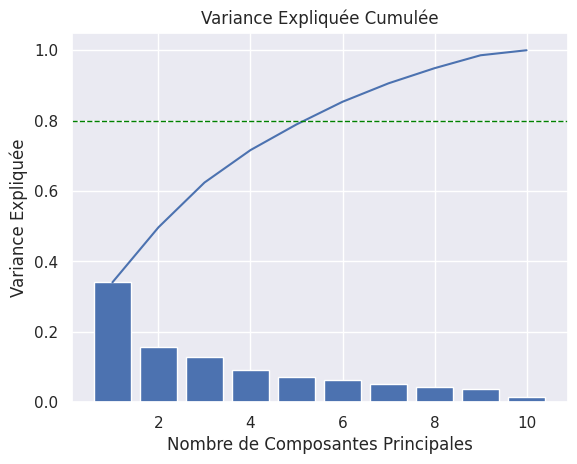

In [446]:
# J'en fais le visuel pour arrêter un choix sur le nombre de composantes à retenir pour les analyses à venir

plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum())
plt.bar(range(1, len(explained_variance) + 1), explained_variance)
# Ligne horizontale pour le seuil de 80%
seuil_80 = 0.8
plt.axhline(y=seuil_80, color='green', linestyle='--', linewidth=1)
plt.title('Variance Expliquée Cumulée')
plt.xlabel('Nombre de Composantes Principales')
plt.ylabel('Variance Expliquée')
plt.show()

## 3.3 ACP

In [447]:
# Je retiens le nombre de  6 composantes et le spécifie ici
n_components = 6

In [448]:
# Initialisation
pca = PCA(n_components=n_components)

In [449]:
# Phase d'apprentissage et de calcul
pca.fit(X_scaled)

PCA(n_components=6)

## 3.4 L'analyse des variables (heatmap et cercles de corrélation)

In [450]:
# Matrice des composantes principales
# Autant de lignes que de composantes principales, autant de colonnes que de variables originelles
pcs = pca.components_
pcs

array([[-0.04137458, -0.29521103,  0.44845946, -0.33125074,  0.48871592,
         0.10954003,  0.42218667,  0.35241739, -0.16658247, -0.13879507],
       [ 0.68896879, -0.45275467,  0.09486234,  0.29771174, -0.10318746,
         0.33161658,  0.1442188 , -0.12006721,  0.14062447,  0.2170171 ],
       [-0.03135077,  0.033594  , -0.08684027, -0.02463594, -0.0454257 ,
         0.15457484, -0.18839222,  0.34111963, -0.59081867,  0.68034006],
       [-0.10899627,  0.28438354, -0.13228022, -0.12427142, -0.01638912,
         0.87480997, -0.08748894,  0.16912429,  0.21373667, -0.16371493],
       [ 0.0072951 ,  0.03000984,  0.04164413,  0.1642434 ,  0.23926356,
        -0.21121687, -0.23794975,  0.56266747,  0.64350132,  0.28489952],
       [ 0.02192932,  0.12656717,  0.0625318 ,  0.76268535,  0.1819661 ,
         0.02906558, -0.08520711,  0.26239852, -0.34029125, -0.41476843]])

In [451]:
# Exemple d'interprétation :
# La variable 9 (Population) influence très fortement la composante principal n°4 (à hauteur de 0.97)

In [452]:
# Je le transforme en dataframe
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8,9
0,-0.041375,-0.295211,0.448459,-0.331251,0.488716,0.109540,0.422187,0.352417,-0.166582,-0.138795
1,0.688969,-0.452755,0.094862,0.297712,-0.103187,0.331617,0.144219,-0.120067,0.140624,0.217017
2,-0.031351,0.033594,-0.086840,-0.024636,-0.045426,0.154575,-0.188392,0.341120,-0.590819,0.680340
3,-0.108996,0.284384,-0.132280,-0.124271,-0.016389,0.874810,-0.087489,0.169124,0.213737,-0.163715
4,0.007295,0.030010,0.041644,0.164243,0.239264,-0.211217,-0.237950,0.562667,0.643501,0.284900
5,0.021929,0.126567,0.062532,0.762685,0.181966,0.029066,-0.085207,0.262399,-0.340291,-0.414768


In [453]:
# Je renomme les colonnes grâce à ma variable features pour retrouver les noms originels
pcs.columns = features
pcs.index = [f"F{i}" for i in range(1, n_components + 1)]
pcs.round(2)

,Population_Log,Taux d'importation nourriture,Score logistique,Tarifs douaniers,PIB_Log,Balance commerciale,Score réglementaire,Disponibilité alimentaire,Taux d'inflation,Distance en Km
F1,-0.04,-0.30,0.45,-0.33,0.49,0.11,0.42,0.35,-0.17,-0.14
F2,0.69,-0.45,0.09,0.30,-0.10,0.33,0.14,-0.12,0.14,0.22
F3,-0.03,0.03,-0.09,-0.02,-0.05,0.15,-0.19,0.34,-0.59,0.68
F4,-0.11,0.28,-0.13,-0.12,-0.02,0.87,-0.09,0.17,0.21,-0.16
F5,0.01,0.03,0.04,0.16,0.24,-0.21,-0.24,0.56,0.64,0.28
F6,0.02,0.13,0.06,0.76,0.18,0.03,-0.09,0.26,-0.34,-0.41


<Axes: >

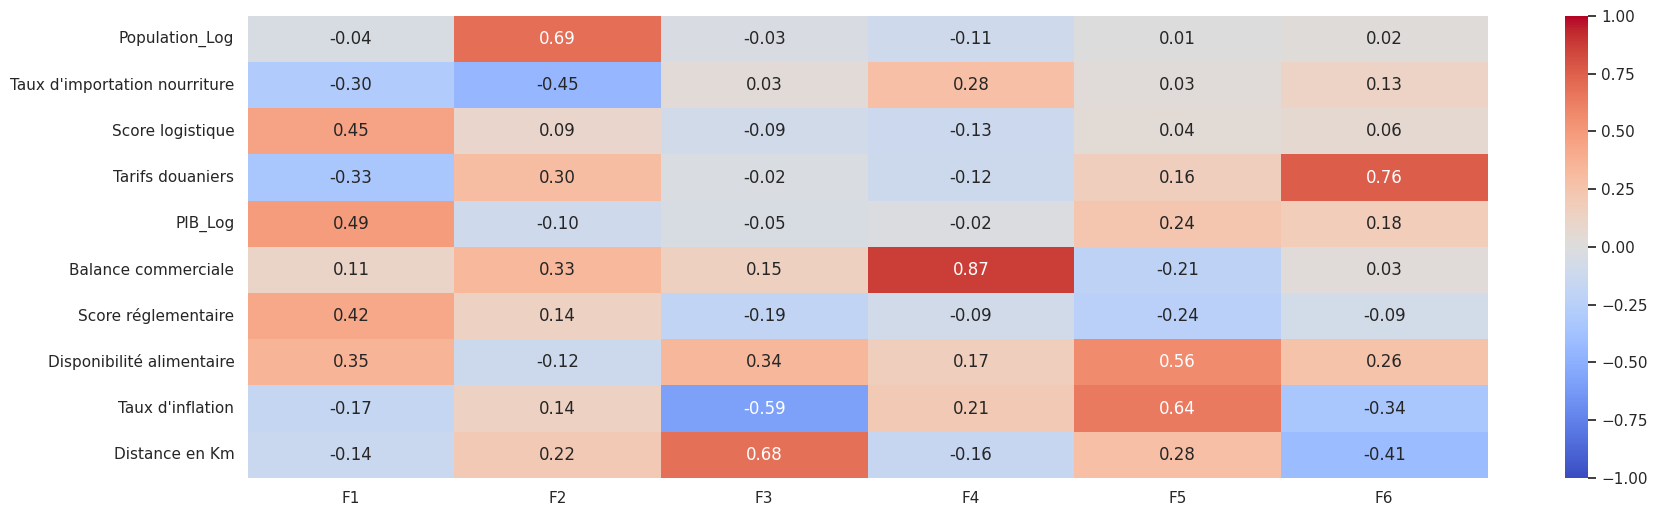

In [454]:
# Je réalise une heatmap pour avoir une première idée de la force des corrélations
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

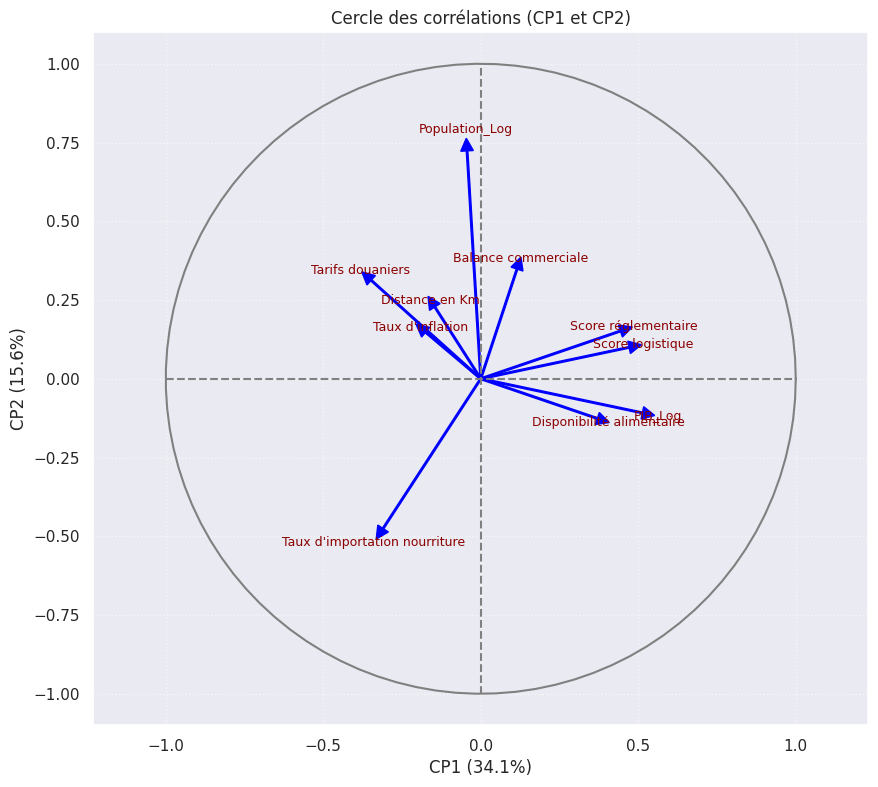

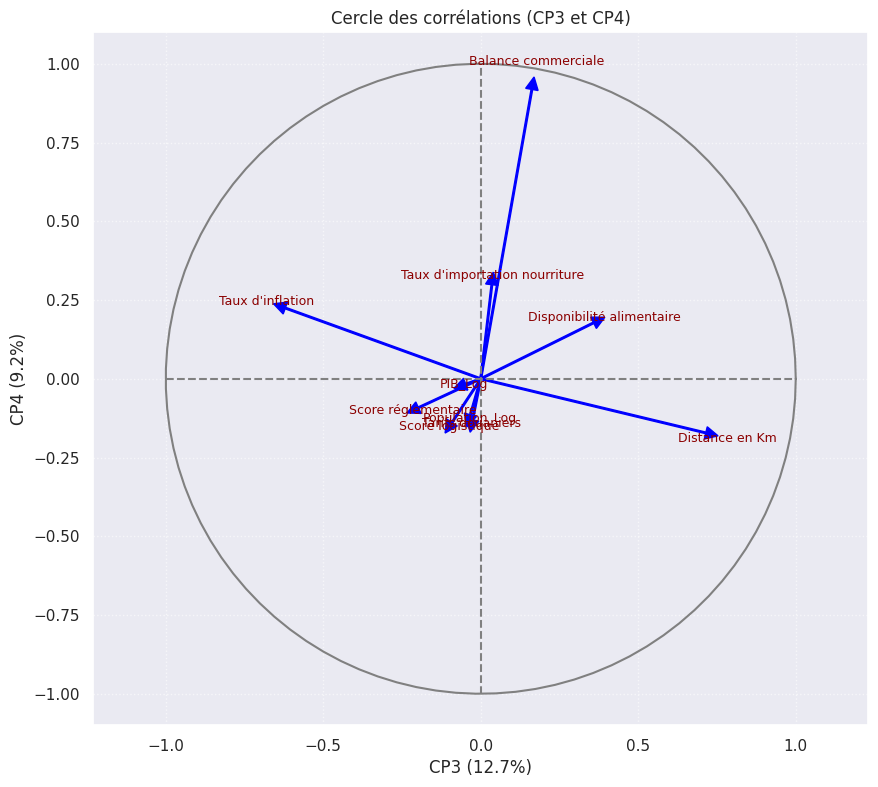

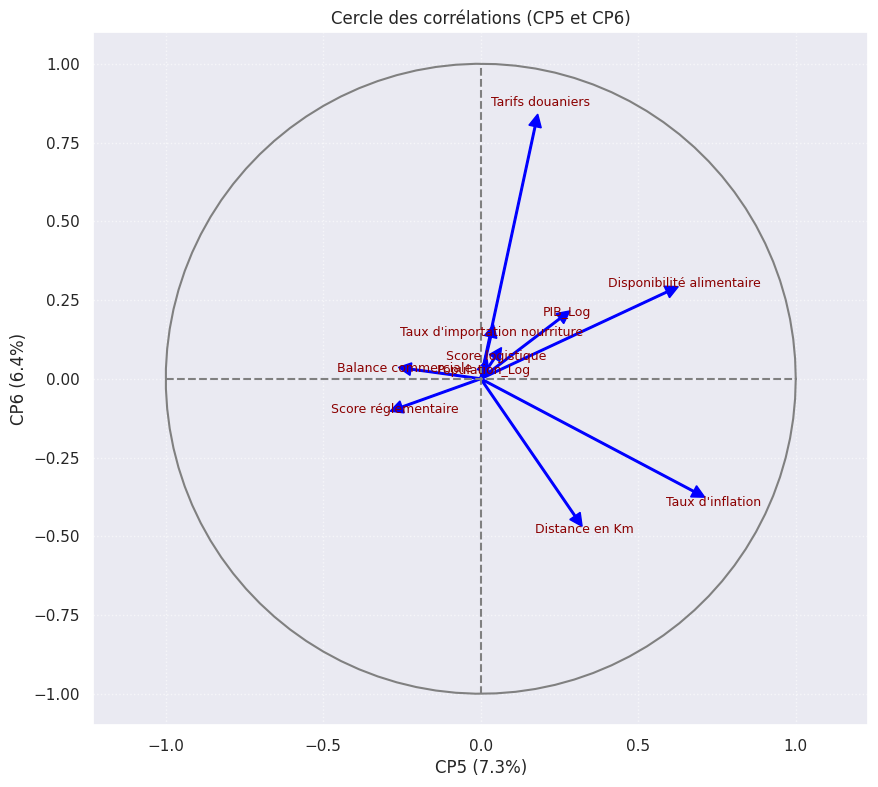

In [455]:
# Pour représenter la manière dont les variables sont liées, je vais représenter les cercles de corrélation

# Nous avons 6 composantes principales, donc nous allons représenter trois cercles
start_axes = [0, 2, 4]

for start_axis in start_axes:
    # Définition des indices pour le plan actuel
    x, y = start_axis, start_axis + 1

    fig, ax = plt.subplots(figsize=(10, 9))

    # Tracé des flèches pour chaque variable
    for i in range(0, pcs.shape[1]):
        # Flèche
        ax.arrow(0,
                 0,
                 pcs.iloc[x, i]* 1.05,
                 pcs.iloc[y, i]* 1.05,
                 head_width=0.04,
                 head_length=0.04,
                 width=0.005,
                 color='blue')

        # Étiquette de la variable
        plt.text(pcs.iloc[x, i] * 1.15,
                 pcs.iloc[y, i] * 1.15,
                 features[i],
                 color='darkred',
                 fontsize=9,
                 ha='center',
                 va='center')

    # Ajout du cercle unitaire (rayon 1)
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an), color='grey', linestyle='-')

    # Lignes horizontales et verticales (axes)
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    inertie_x = round(100 * pca.explained_variance_ratio_[x], 1)
    inertie_y = round(100 * pca.explained_variance_ratio_[y], 1)

    plt.xlabel(f'CP{x+1} ({inertie_x}%)')
    plt.ylabel(f'CP{y+1} ({inertie_y}%)')

    plt.title(f"Cercle des corrélations (CP{x+1} et CP{y+1})")

    # Mise en forme finale
    plt.axis('equal') # Assure que le cercle est rond
    plt.grid(linestyle=':', alpha=0.6)
    plt.show()

**Le Premier Plan Factoriel (CP1, CP2), qui représente 49,7% de l'information**

**CP1 (34,1%)** : L'axe "Ouverture commerciale" et développement économique

Ce qu'il oppose :

À droite, on trouve les indicateurs de stabilité et de
richesse (PIB_Log, Score logistique, Score réglementaire). Ces variables sont très proches les une des autres, elles semblent fortement corrélées. Les pays riches semblent donc avoir une capacité logistique forte.

À gauche, on trouve des compléments d'informations aux précédentes données : tarifs douaniers et taux d'importation de nourriture vont dans le même sens sur l'axe 2 (mais divergent complètement sur l'axe 1). Elles ne sont pas dans le même quart de cercle. Les pays les plus peuplés ont des barrières douanière plus fortes et importent moins, et c'est le contraire pour les pays faiblement peuplés (ne pouvant être auto suffisants)

Potentiel : Pour l'export, les pays avec une valeur élevé sur l'axe CP1 peuvent être des destinations intéressantes (avec une vigilance sur les tarifs douaniers)

**CP2 (15.6%)** : L'axe "Géants exportateurs"

Ce qu'il représente : Il est tiré très fortement vers le haut par la variable de population et dans une moindre mesure par la balance commerciale.

Dans le sens négatif, le taux d'importation de nourriture est fort. Il semble y avoir une corrélation négative entre les dimensions de population et le taux d'importation de nourriture. Cela désigne des pays fortement peuplés et autosuffisants.

Interprétation : Cet axe sépare les "géants" exportateurs (en haut) des pays moins peuplés  et plus dépendants de leur importations.


---


**Le Deuxième Plan (CP3 et CP4) - 21.9 % de l'information**

**CP3 (12.7%)** : L'axe géographique

L'Axe Horizontal (CP3 - 12.7% de variance) :

Cet axe horizontal est presque exclusivement dominé par une seule variable :  la distance, c'est la variable la plus corrélée positivement avec cet axe. On relève aussi la disponibilité alimentaire, ces pays éloignés de la France (et donc de la zone Europe) ont une disponibilité alimentaire relativement forte dans notre échantillon.
Dans le sens négatif, le taux d'inflation contribue fortement, ce sont des pays avec une inflation très forte, et par extension plus proche de la France (car l'axe est en opposition avec la distance).

**CP4 (9,2)** : L'axe des acteurs majeurs du commerce international"

Ce qu'il représente : La variable majeure est ici la balance commerciale (flèche vers le haut de manière presque isolée) et dans une mojndre mesure le taux d'importation de nourriture.

Interprétation : Ce sont des pays qui sont d'importants acteurs du commerce internationale, et cela en leur faveur (balance commerciale positive élevée). Une partie de leur disponibilité alimentaire provient des importations.



**Le troisième plan : CP5 / CP6 - 13,7% de l'inertie (A ce stade, les interprétations doivent être plus mesurées au regard du pourcentage d'informations des données captée)**

**CP5 (7.3%)** : L'instabilité monétaire

Cet axe semble capturer une spécificité résiduelle liée aux tensions monétaires. Il isole les pays qui, indépendamment de leur richesse (CP1) ou de leur taille (CP2), subissent une forte inflation tout en ayant une disponibilité alimentaire correcte.


**CP6 (6.4%)** : L'axe "Protectionnisme et éloignement"

Ce qu'il représente : Les Tarifs douaniers sont très forts ici, ce sont les pays avec des barrières douanières fortes.
A contrario, on voit vers le bas (valeurs négatives) la distance en km. Elle est opposée négativement aux tarifs douaniers. Les pays les plus lointains de la France (et donc de la zone Europe) seraient moins enclins à taxer leur marchandises pour favoriser leur commerce internationale.



## 3.5 Projection

In [456]:
# Transformation des données brutes issues de l'ACP en coordonnées factorielles
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[-1.67401814, -1.01638805, -0.0384019 ,  0.56064393,  0.59909032,
         0.99042519],
       [ 1.02089404, -0.81915059, -1.3703983 ,  0.31129471, -0.53280409,
        -0.78084912],
       [-1.25384574,  0.41816026,  1.77869383, -0.68630999, -0.47016207,
        -2.38758331],
       [-2.19099785,  1.8985583 , -0.08547565, -0.84488474, -1.00379563,
        -0.39959091],
       [-1.75103383, -1.8058027 ,  0.70269863,  0.41705905, -0.35255389,
        -0.82964831]])

In [457]:
# Création d'un DataFrame avec les scores projetés
X_proj_df = pd.DataFrame(
    X_proj,
    columns=[f'PC{i+1}' for i in range(X_proj.shape[1])]
)

# Je récupère la future clé de jointure ('Country Code')
X_proj_df['Country Code'] = df['Country Code'].values


X_proj_df.head(5)

,PC1,PC2,PC3,PC4,PC5,PC6,Country Code
0,-1.674018,-1.016388,-0.038402,0.560644,0.599090,0.990425,LBY
1,1.020894,-0.819151,-1.370398,0.311295,-0.532804,-0.780849,SRB
2,-1.253846,0.418160,1.778694,-0.686310,-0.470162,-2.387583,PNG
3,-2.190998,1.898558,-0.085476,-0.844885,-1.003796,-0.399591,COD
4,-1.751034,-1.805803,0.702699,0.417059,-0.352554,-0.829648,SWZ


In [458]:
# Je renomme la colonne qui servira de clé
countries_gdf = countries_gdf.rename(columns={'ISO3166-1-Alpha-3': 'Country Code'})

# Je fais la fusion
map_gdf = countries_gdf.merge(X_proj_df, on='Country Code', how='left')

# Vérification
map_gdf.head(5)

,name,Country Code,ISO3166-1-Alpha-2,geometry,PC1,PC2,PC3,PC4,PC5,PC6
0,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4...",-0.087350,1.733050,1.292336,-0.789239,-0.275585,-0.854276
1,Malaysia,MYS,MY,"MULTIPOLYGON (((117.70361 4.16342, 117.69711 4...",2.271000,0.620385,1.632988,-0.837817,1.015881,-0.367008
2,Chile,CHL,CL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...",0.752725,0.304172,1.434724,-0.188065,1.067416,-0.691121
3,Bolivia,BOL,BO,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...",0.104859,0.462403,1.776731,-0.355451,0.685496,0.145442
4,Peru,PER,PE,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...",0.639485,0.055052,1.606687,-0.189283,0.848628,-0.836540


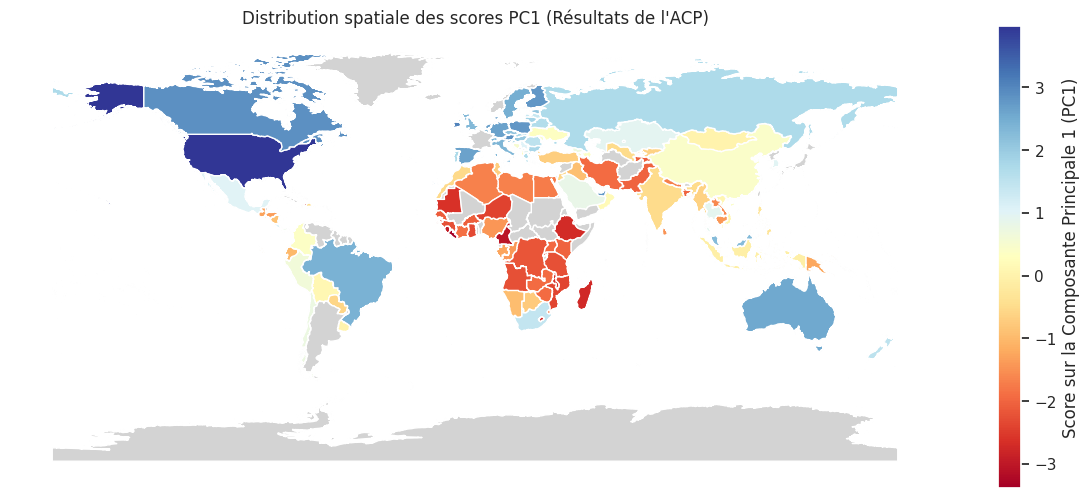

In [459]:
# Cartographie de la Composante Principale 1

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

map_gdf.plot(
    column='PC1',               # Cartographie de la Composante Principale 1
    ax=ax,
    legend=True,
    cmap='RdYlBu',
    legend_kwds={
        'label': "Score sur la Composante Principale 1 (PC1)",
        'shrink': 0.6
    },
    missing_kwds={"color": "lightgrey", "label": "Données non incluses"}
)

ax.set_title("Distribution spatiale des scores PC1 (Résultats de l'ACP)")
ax.set_axis_off()
plt.savefig("PC1_map.png")

Pour rappel l'axe 1 celui de la richesse mais aussi des infrastructures et de la régulation. Il y une distinction assez nette ici entre d'un côté les pays aux économies fortes ET ouvertes.

Zones Bleues (Positives) : USA, Australie, Brésil et l'Europe

Opportunité Bio : Marché stable mais probablement saturé et très concurrentiel.

Zones Rouges (Négatives) : Afrique (notamment Afrique de l'Ouest et Centrale).

Forte dépendance aux importations alimentaires (vecteur Taux d'importation vers la gauche), mais également : le vecteur Tarifs douaniers pointe aussi vers ce côté gauche/haut.

Risque : Le pouvoir d'achat de ces pays ne semblent pas correspondre à notre gamme de produits et les tarifs dounaiers sont élevés.

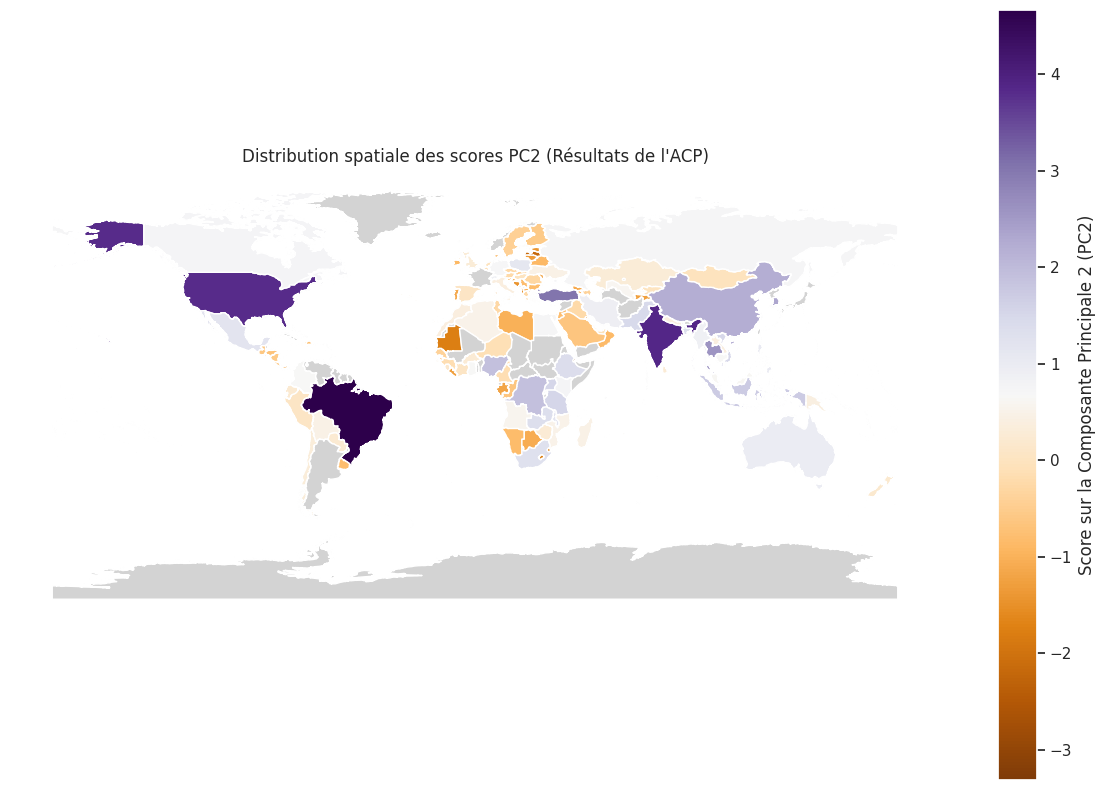

In [460]:
# Cartographie de la Composante Principale 2

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

map_gdf.plot(
    column='PC2',
    ax=ax,
    legend=True,
    cmap='PuOr',
    legend_kwds={'label': "Score sur la Composante Principale 2 (PC2)"},
    missing_kwds={"color": "lightgrey", "label": "Données non incluses"}
)

ax.set_title("Distribution spatiale des scores PC2 (Résultats de l'ACP)")
ax.set_axis_off()
plt.show()

Ici, la puissance démographique des deux grandes puissances écrase tout le contraste.
Zones Violettes (Positives) : Chine, Inde.

Signification : Ce sont des pays très peuplés et qui s'organisent pour ne pas dépendre des importations.

Opportunité Bio : Volume potentiel de clients esténorme, mais il faut faire face à une concurrence nationale potentiellement forte. Axer sur l'aspect premium du produit peut être une stratégie marketing.


On retrouve ici deux pays qui se démarquant nettement, la Chine et l'Inde, la po

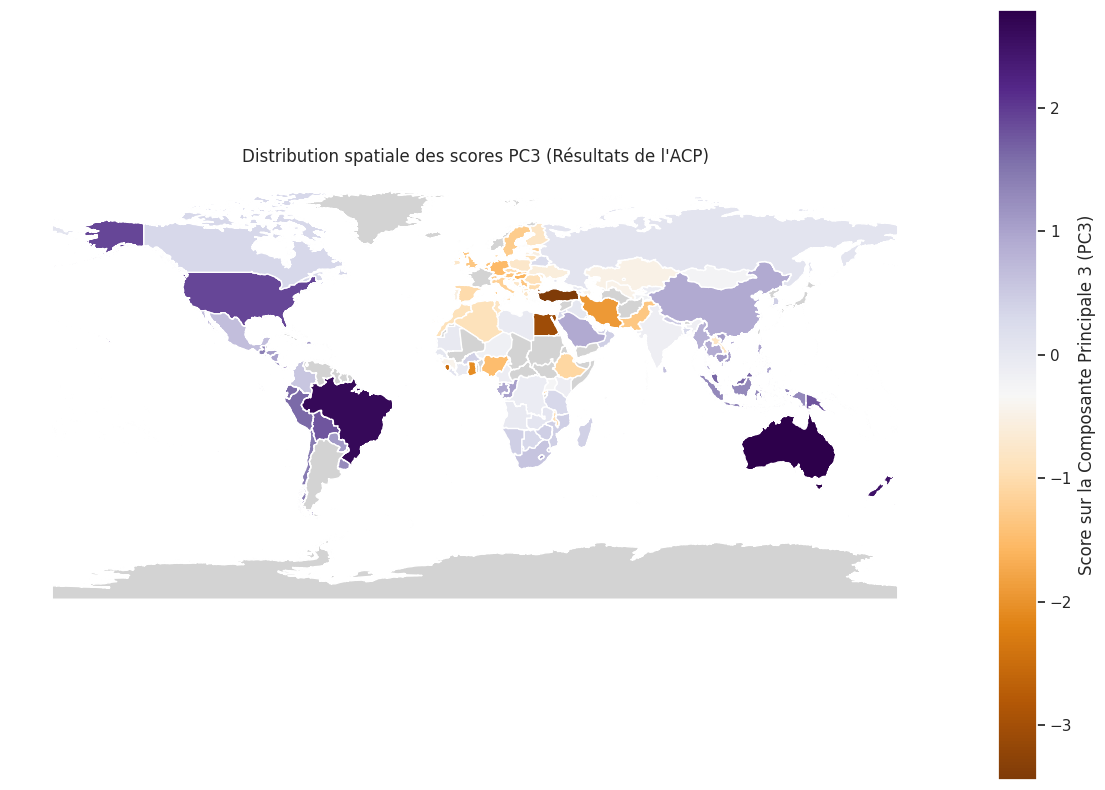

In [461]:
# Cartographie de la Composante Principale 3

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

map_gdf.plot(
    column='PC3',
    ax=ax,
    legend=True,
    cmap='PuOr',
    legend_kwds={'label': "Score sur la Composante Principale 3 (PC3)"},
    missing_kwds={"color": "lightgrey", "label": "Données non incluses"}
)

ax.set_title("Distribution spatiale des scores PC3 (Résultats de l'ACP)")
ax.set_axis_off()
plt.show()

Le constraste se fait ici sur la distance géographique, plus les pays sont loin, plus ils ont un score important dans cette dimension puisque c'est la variable qui contribue le plus à la CP3. En plus de cet éloignement, ces pays ont une disponibilité alimentaire élevé et ne semblent pas des marchés prometteurs sans une stratégie marketing précise (produit premium : le bio).

In [462]:
# En plus des cartes, je souhaite représenter les deux premiers axes de mon acp sous la forme d'un nuage de points.
# Je choisis d'y projeter les deux premières variables, les plus constitutives de mon ACP.
# Je créé un df temporaire
plot_df = df.copy()
plot_df['Axe F1'] = X_proj[:, 0]
plot_df['Axe F2'] = X_proj[:, 1]

# Création du graphique enrichi
fig = px.scatter(
    plot_df,
    x="Axe F1",
    y="Axe F2",
    hover_name="Country Name",

    # J'utilise les attributs siez et color pour rendre le graphique plus lisible
    color="PIB_Log",
    size="Population",

    # Options esthétiques
    color_continuous_scale="Viridis",
    size_max=40,
    hover_data=["Score logistique", "Distance en Km"], # Complement d'infos avec les autres variables ressortant sur le premier plan factoriel

    title="Projection ACP Interactive (Couleur=Richesse, Taille=Population)",
    height=700
)

#Les axes du graphique
fig.add_hline(y=0, line_width=1, line_color="grey", line_dash="dash")
fig.add_vline(x=0, line_width=1, line_color="grey", line_dash="dash")

# Ajout d'un fond
fig.update_layout(
    plot_bgcolor='rgba(240,240,240,0.5)',
    hovermode='closest'
)

fig.show()

# 4 Clustering - Classification hiérarchique

## 4.1 Classification ascendante hiérarchique

### 4.1.2 Modélisation Hiérarchique (CAH)

In [463]:
# Je reprends les données issues de l'ACP et utilise la méthode Ward pour analyser comment les pays peuvent se regrouper
Z = linkage(X_proj, method="ward")
Z[:10]

array([[ 57.        , 118.        ,   0.30456784,   2.        ],
       [ 68.        , 102.        ,   0.34190738,   2.        ],
       [ 17.        ,  77.        ,   0.39429163,   2.        ],
       [ 30.        ,  52.        ,   0.41649933,   2.        ],
       [ 31.        ,  40.        ,   0.42610551,   2.        ],
       [ 63.        , 125.        ,   0.47561359,   2.        ],
       [ 20.        ,  21.        ,   0.48648563,   2.        ],
       [ 72.        , 124.        ,   0.49064575,   2.        ],
       [ 73.        ,  93.        ,   0.49098367,   2.        ],
       [ 58.        , 116.        ,   0.50466486,   2.        ]])

In [464]:
# Je définis ces deux variables pour les utiliser dans des visuels par la suite
countries = df['Country Name'].values
regions = df['Sub-region Name'].values

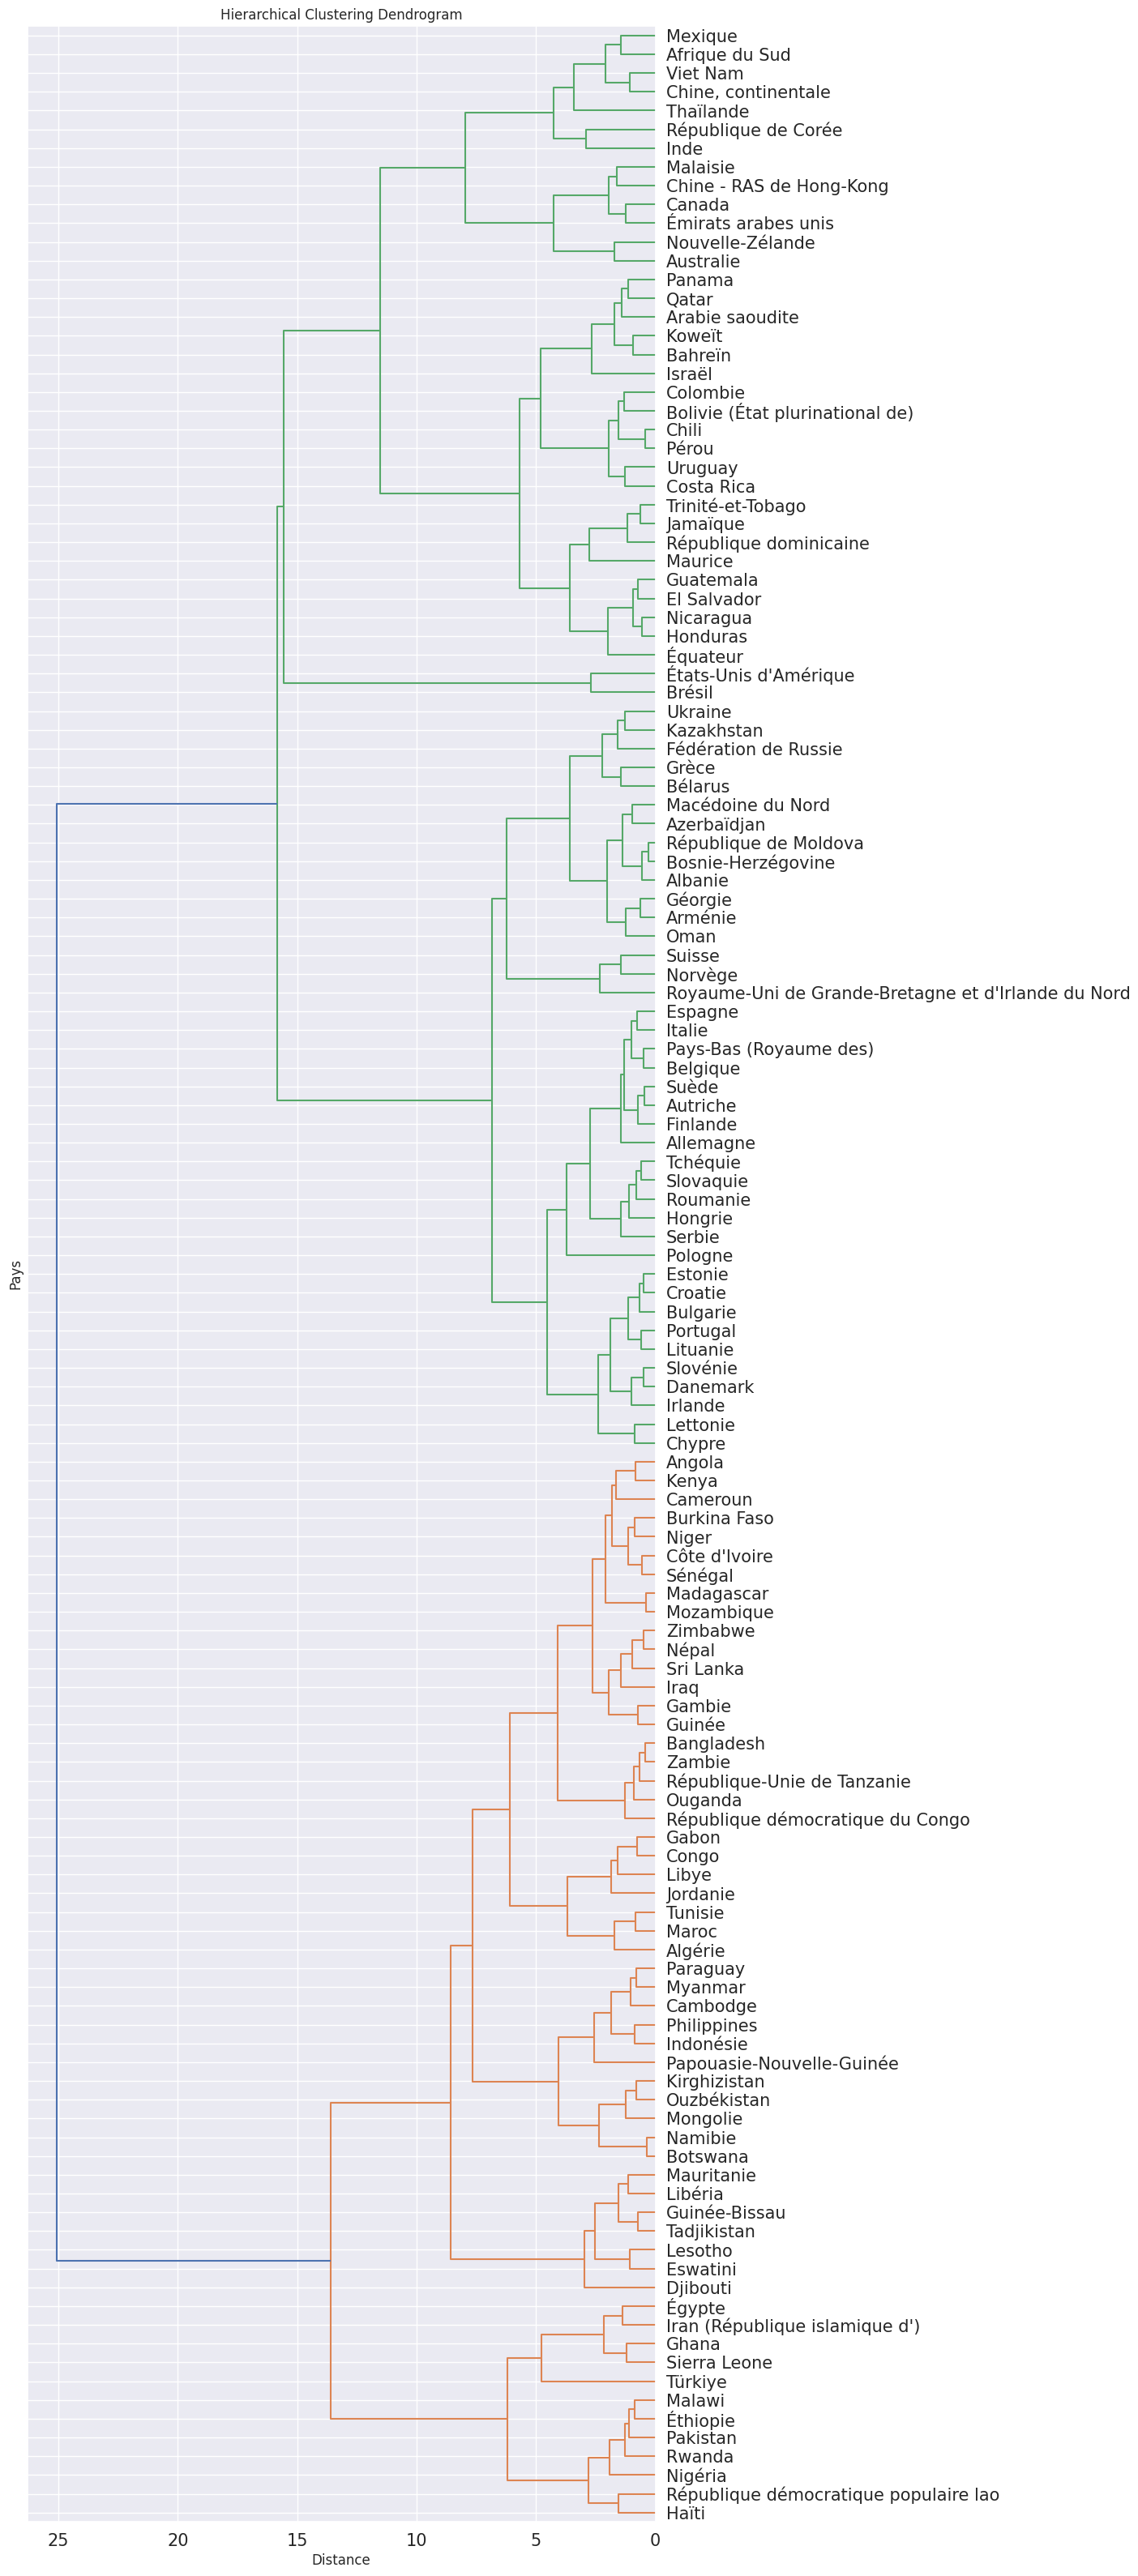

In [465]:
# Je réalise mon dendrogramme grâce aux données obtenues

fig, ax = plt.subplots(1, 1, figsize=(10,40))

_ = dendrogram(Z, ax=ax, labels=countries, orientation = "left")

plt.title("Hierarchical Clustering Dendrogram")
ax.set_xlabel("Distance")
ax.set_ylabel("Pays")
ax.tick_params(axis='x', which='major', labelsize=15)
ax.tick_params(axis='y', which='major', labelsize=15)

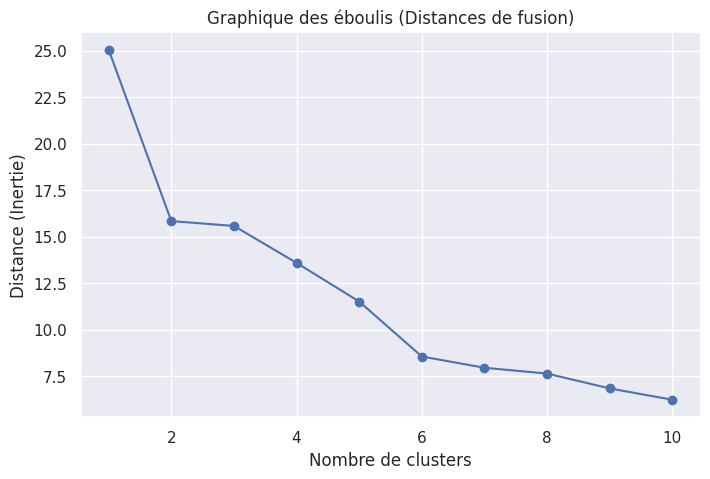

In [466]:
# Réalisation d'un graphique des éboulis pour mesurer la bonne partition

last = Z[-10:, 2]
last_rev = last[::-1]
idxs = range(1, len(last) + 1)

plt.figure(figsize=(8, 5))
plt.plot(idxs, last_rev, marker='o')
plt.title('Graphique des éboulis (Distances de fusion)')
plt.xlabel('Nombre de clusters')
plt.ylabel('Distance (Inertie)')
plt.grid(True)
plt.show()

Le graphique des éboulis  met en évidence un premier coude très net au niveau de 2 clusters puis un plateau de 2 à 3. La courbe diminue progressivement jusqu'à 6 avant de marquer de nouveau un ralentissement.
Je retiens 6 clusters dans une logique métier afin d'affiner le choix le plus possible.

### 4.1.3 Clusters

In [467]:
# Je détermine le nombre de cluters
k=6

In [468]:
# J'affecte chaque pays à un cluster
clusters_CAH = fcluster(Z, k, criterion='maxclust')
clusters_CAH

array([2, 3, 2, 2, 2, 3, 6, 1, 1, 2, 2, 1, 2, 2, 3, 2, 1, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 3, 1, 5, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3,
       3, 5, 1, 2, 2, 2, 2, 2, 5, 6, 6, 3, 5, 3, 3, 3, 2, 5, 6, 3, 6, 6,
       2, 5, 2, 4, 3, 2, 3, 3, 5, 5, 6, 2, 5, 3, 3, 5, 3, 5, 5, 3, 5, 1,
       3, 2, 2, 3, 3, 3, 4, 5, 3, 5, 6, 3, 2, 3, 2, 6, 3, 3, 3, 5, 6, 2,
       3, 1, 5, 3, 5, 2, 3, 6, 3, 1, 5, 3, 3, 3, 3, 3, 5, 6, 3, 1, 3, 5,
       6], dtype=int32)

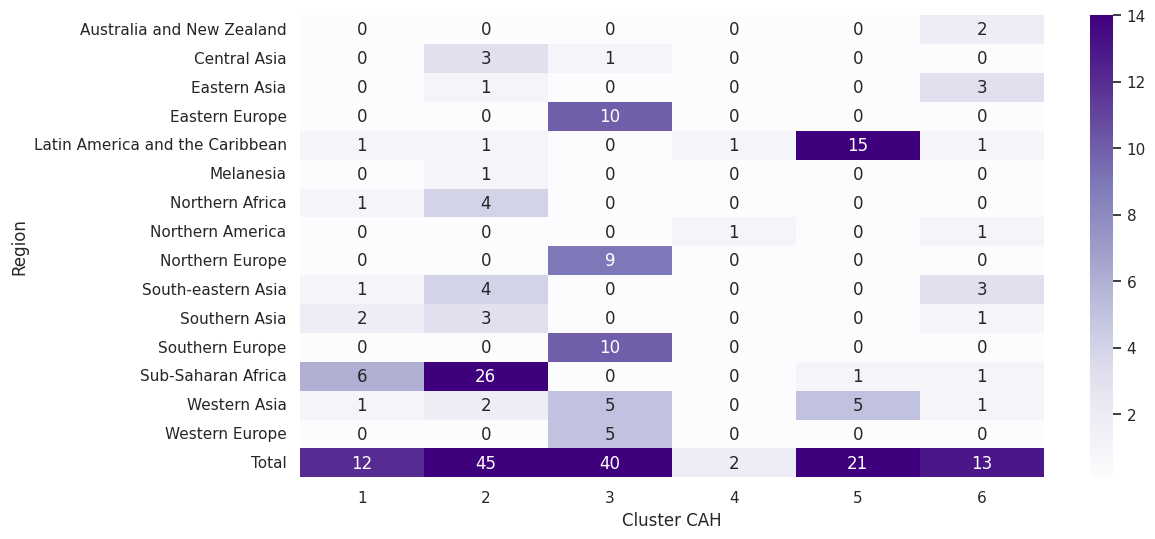

In [469]:
# Je créé un tableau pour voir la répartition des pays par région et par clusters
crosstab = pd.crosstab(regions, clusters_CAH, margins=True, margins_name="Total")
crosstab.rename_axis(columns="Cluster CAH", index="Region", inplace=True)

# SUPPRESSION DE LA COLONNE TOTAL
# Syntaxe .iloc : [toutes_les_lignes , toutes_les_colonnes_sauf_la_dernière]
crosstab_clean = crosstab.iloc[:, :-1]

# Je représente cette répartition sous la forme d'une heatmap
fig, ax = plt.subplots(1,1, figsize=(12,6))
ax = sns.heatmap(crosstab_clean, vmin=0.1, vmax=14, annot=True, cmap="Purples")

In [470]:
df.index = names
X_proj_df.index = names

# 1. On l'ajoute dans le dataframe de projection (pour les graphiques ACP)
X_proj_df['Cluster CAH'] = clusters_CAH

# 2. On l'ajoute SURTOUT dans le dataframe original (pour l'analyse métier)
df['Cluster CAH'] = clusters_CAH

print(df['Cluster CAH'].value_counts())


Cluster CAH
2    45
3    40
5    21
6    13
1    12
4     2
Name: count, dtype: int64


In [471]:
# J'affiche la liste des pays par clusters
for i in sorted(df['Cluster CAH'].unique()):
    pays_cluster = df[df['Cluster CAH'] == i].index.tolist()
    print(f"\n--- Cluster CAH {i} ({len(pays_cluster)} pays) ---")
    print(", ".join(pays_cluster))


--- Cluster CAH 1 (12 pays) ---
Éthiopie, Haïti, Iran (République islamique d'), Malawi, Sierra Leone, Pakistan, Rwanda, Égypte, Ghana, Nigéria, République démocratique populaire lao, Türkiye

--- Cluster CAH 2 (45 pays) ---
Libye, Papouasie-Nouvelle-Guinée, République démocratique du Congo, Eswatini, Myanmar, Maroc, Iraq, Djibouti, Tunisie, Mozambique, Tadjikistan, Népal, Zimbabwe, Sri Lanka, Sénégal, Ouzbékistan, Ouganda, République-Unie de Tanzanie, Zambie, Niger, Libéria, Lesotho, Kirghizistan, Kenya, Mauritanie, Congo, Bangladesh, Côte d'Ivoire, Algérie, Mongolie, Guinée, Jordanie, Guinée-Bissau, Cameroun, Angola, Cambodge, Botswana, Burkina Faso, Madagascar, Gambie, Gabon, Indonésie, Namibie, Philippines, Paraguay

--- Cluster CAH 3 (40 pays) ---
Serbie, Fédération de Russie, Bélarus, Roumanie, Azerbaïdjan, Albanie, Arménie, Chypre, Bosnie-Herzégovine, Belgique, Allemagne, Autriche, Bulgarie, Danemark, Croatie, Lituanie, Kazakhstan, Italie, Lettonie, Géorgie, Finlande, Espagne, 

## 4.2 K-Means

In [472]:
# J'essaie une autre méthode de clustering : le K-means
# Préparation
# On crée une liste vide pour stocker les résultats (les scores d'inertie) de nos tests
inertia = []

In [473]:
# Je définis la plage de test : de 1 à 9 clusters
k_list = range(1, 10)
list(k_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [474]:
# Je définis la boucle de test
for i in k_list :
  #On configure le modèle pour chercher 'i' groupes
  kmeans = KMeans(n_clusters=i)
  # J'entraîne le modèle sur nos données projetées (qui proviennent de l'ACP)
  kmeans.fit(X_proj)
  # Je récupère le score d'inertie  et l'ajoute à la liste
  inertia.append(kmeans.inertia_)

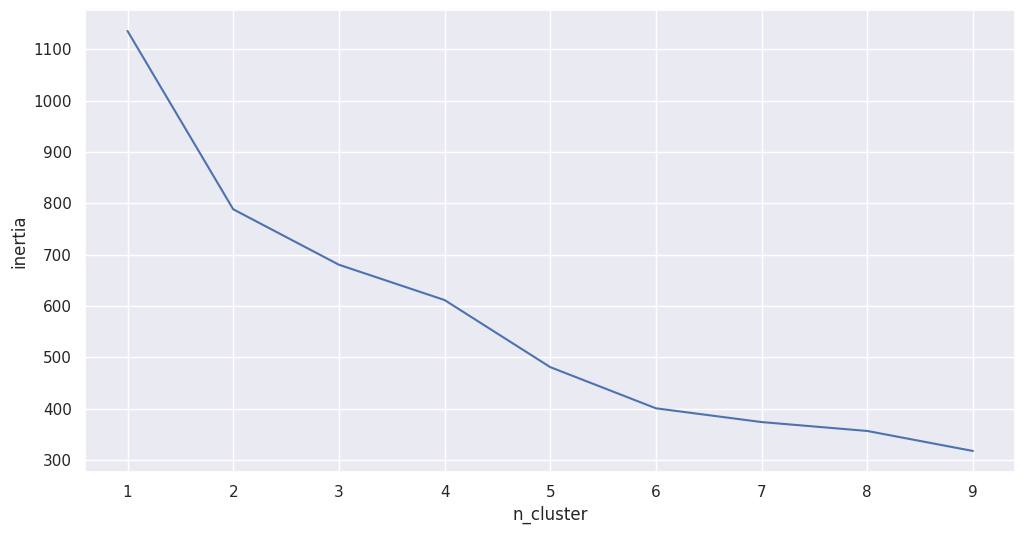

In [475]:
# Je génère le graphique de la méthode du coude pour aider à la décision du nombre de clusters à retenir
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("inertia")
ax.set_xlabel("n_cluster")
ax = plt.plot(k_list, inertia)

La courbe descend régulièrement jusqu'à atteindre le chiffre de 5 clusters. De 5 à 6, la courbe est quasi stable, il n'est pas significatif d'aller au-delà de 5 clusters, l'inertie ne baisse plus ou pratiquement plus.

In [476]:
# POur compléter cette première lecture, je calcule le score de Silhouette (qui mesure si les points sont proches de leur centre, l'inertie,
# mais aussi si les centres des différents groupes sont bien séparés)

# On teste les candidats potentiels (2, 3, 4, 5, 6)
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_proj)
    score = silhouette_score(X_proj, km.labels_)
    print(f"Pour k = {k}, le score de silhouette est de : {score:.3f}")

Pour k = 2, le score de silhouette est de : 0.299
Pour k = 3, le score de silhouette est de : 0.209
Pour k = 4, le score de silhouette est de : 0.243
Pour k = 5, le score de silhouette est de : 0.251
Pour k = 6, le score de silhouette est de : 0.228


Cela confirme la première lecture, le meilleure score est pour 2 clusters, mais ensuite c'est pour 5 clusters que le découpage est le meileur (la valeur plus proche de 1). Je confirme donc le choix de 5 clusters.

In [477]:
# A titre d'expérimentation, je lance une simulation du K-Means avec 5 clusters
# On va faire 5 essais avec des "graines" aléatoires différentes
print("--- Observation de l'instabilité du K-Means standard ---")

for i in range(5):
    # On change le random_state à chaque tour (i = 0, 1, 2, 3, 4)
    kmeans_test = KMeans(n_clusters=5, random_state=i, n_init=10)
    kmeans_test.fit(X_proj)

    # On compte la taille des groupes
    effectifs = pd.Series(kmeans_test.labels_).value_counts().sort_index()

    print(f"\nEssai n°{i+1} (Graine {i}) :")
    print(effectifs.to_string())
    print("-" * 30)

--- Observation de l'instabilité du K-Means standard ---

Essai n°1 (Graine 0) :
0    48
1    40
2     2
3    12
4    31
------------------------------

Essai n°2 (Graine 1) :
0    41
1    12
2    54
3     2
4    24
------------------------------

Essai n°3 (Graine 2) :
0    32
1    12
2    44
3     2
4    43
------------------------------

Essai n°4 (Graine 3) :
0    43
1    44
2    12
3     2
4    32
------------------------------

Essai n°5 (Graine 4) :
0    31
1    12
2    44
3    44
4     2
------------------------------


Malgé une certaine variabilité dans la composition des clusters, on observe des tendances : il y a toujours un cluster avec 2 pays et un autre de 12 pays. Ces pays semblent de distinguer du reste.

In [478]:
# Je fixe random_state=42 pour garantir la reproductibilité des résultats
kmeans5 = KMeans(n_clusters=5, random_state=42)
cluster_kmeans = kmeans5.fit_predict(X_proj)

# 2. Ajouter au DataFrame (en supposant que 'df' est votre dataframe original avec les noms des pays)
df['Cluster K_means'] = cluster_kmeans

# 3. Vérifier la répartition
print(df['Cluster K_means'].value_counts())

Cluster K_means
4    42
1    36
0    25
3    18
2    12
Name: count, dtype: int64


In [479]:
kmeans.labels_

array([3, 1, 2, 7, 0, 1, 5, 4, 4, 2, 7, 4, 7, 0, 1, 7, 4, 7, 4, 0, 7, 7,
       7, 7, 2, 4, 7, 7, 1, 4, 8, 7, 7, 0, 0, 2, 7, 0, 3, 1, 7, 7, 7, 1,
       1, 3, 4, 2, 7, 3, 0, 7, 8, 5, 2, 1, 8, 1, 1, 1, 7, 8, 5, 1, 5, 5,
       2, 8, 3, 6, 1, 7, 1, 1, 2, 8, 5, 7, 8, 1, 1, 5, 1, 3, 8, 1, 3, 4,
       1, 7, 3, 1, 1, 1, 6, 3, 1, 3, 2, 1, 2, 1, 3, 5, 1, 5, 1, 8, 5, 2,
       5, 4, 3, 3, 8, 2, 1, 8, 1, 4, 3, 1, 5, 1, 1, 1, 8, 2, 1, 4, 1, 8,
       2], dtype=int32)

## 4.3 Comparaison des clusterings entre les méthodes ACP et K-Means

In [480]:
# Je compare les répartitions des deux méthodes
# - clusters_cah : 5
# - clusters_kmeans : 6

# On crée un tableau croisé
comparaison = pd.crosstab(clusters_CAH, cluster_kmeans)
comparaison.index.name = "Clusters CAH"
comparaison.columns.name = "Clusters K-Means Simple"

print("Tableau de correspondance entre CAH et K-Means :")
display(comparaison)

Tableau de correspondance entre CAH et K-Means :


Clusters K-Means Simple,0,1,2,3,4
Clusters CAH,,,,,
1,0,0,12,0,0
2,3,0,0,2,40
3,8,32,0,0,0
4,0,0,0,2,0
5,14,1,0,4,2
6,0,3,0,10,0


**Les points communs  :**

La première ligne regroupe 12 pays, les deux méthodes ont la même composition pour ce cluster, tout comme la ligne 4.

**Les divergences :**

La 2ème ligne met en lumière que 40 pays sont commun aux deux méthodes au sein de ce cluster, 5 pays sont basculés dans d'autres clusters selon le K-means.

Les lignes 3 et 5 sont celles qui marquent le plus les différences.

In [481]:
# Résumé des clusters selon les deux méthodes :
print("--- Effectifs par méthode ---")
print(df['Cluster CAH'].value_counts())
print(df['Cluster K_means'].value_counts())

--- Effectifs par méthode ---
Cluster CAH
2    45
3    40
5    21
6    13
1    12
4     2
Name: count, dtype: int64
Cluster K_means
4    42
1    36
0    25
3    18
2    12
Name: count, dtype: int64


## 4.4 K-Means à partir des données de l'ACH

### 4.4.1 Le K-means hybride

In [482]:
# POur un résultat optimal, je vais opter pour une méthode hybrique. Je vais utiliser l'algorithme du K-Means à partir de données fournies
# par la classification ascendante hiérarchique
# -------------------------------------------------
# Je crée un tableau temporaire avec les coordonnées ACP (PC1, PC2, etc.) et j'en fais un dataframe
df_temp = pd.DataFrame(X_proj)

# J'ajoute une colonne avec les groupes trouvés par la méthode CAH
df_temp['Cluster_CAH'] = clusters_CAH

# Je calcule la moyenne de chaque colonne (PC1, PC2...) pour chaque groupe
# Ce sont les "centroïdes" initiaux
centroides_cah = df_temp.groupby('Cluster_CAH').mean().values

print("Voici les coordonnées des 6 centres issus de la CAH :")
print(centroides_cah)

Voici les coordonnées des 6 centres issus de la CAH :
[[-2.12029756  1.04221226 -1.72568654  0.45472027  1.4138404  -0.64199996]
 [-1.65135679 -0.04153112  0.2286793  -0.10564521 -0.51258661  0.08020725]
 [ 1.73005049 -0.51545155 -0.8391095   0.03491642 -0.37642608 -0.03470122]
 [ 3.19209139  4.23173491  2.27814937  5.69475894 -0.81914887  0.3128092 ]
 [ 0.21191151 -0.76805971  1.24694026  0.10555106  0.82537275  0.26262509]
 [ 1.51679094  1.35739996  1.01846199 -1.20810428  0.42021738 -0.05061719]]


In [483]:
# Je configure le K-Means avec les paramètres choisis à partir des précédents résultats
kmeans_hybride = KMeans(n_clusters=6, init=centroides_cah, n_init=1, random_state=42)

# J'entraîne le modèle final
kmeans_hybride.fit(X_proj)

# Je récupère les étiquettes finales (optimisées)
labels_hybrides = kmeans_hybride.labels_

In [484]:
# J'ajoute les résultats de cette nouvelle répartition dans le DataFrame principal
df['Cluster_Final'] = labels_hybrides

print("Répartition finale après consolidation par K-Means :")
print(df['Cluster_Final'].value_counts())

Répartition finale après consolidation par K-Means :
Cluster_Final
1    42
2    39
4    21
5    17
0    12
3     2
Name: count, dtype: int64


In [485]:
# Affiche les pays groupés par cluster
for cluster in sorted(df['Cluster_Final'].unique()):
    pays = df[df['Cluster_Final'] == cluster]['Country Name'].values
    print(f"\n--- CLUSTER {cluster} ({len(pays)} pays) ---")
    print(pays)


--- CLUSTER 0 (12 pays) ---
['Éthiopie' 'Haïti' "Iran (République islamique d')" 'Malawi'
 'Sierra Leone' 'Pakistan' 'Rwanda' 'Égypte' 'Ghana' 'Nigéria'
 'République démocratique populaire lao' 'Türkiye']

--- CLUSTER 1 (42 pays) ---
['Libye' 'Papouasie-Nouvelle-Guinée' 'République démocratique du Congo'
 'Eswatini' 'Myanmar' 'Maroc' 'Iraq' 'Djibouti' 'Tunisie' 'Mozambique'
 'Tadjikistan' 'Népal' 'Zimbabwe' 'Sri Lanka' 'Sénégal' 'Ouzbékistan'
 'Ouganda' 'République-Unie de Tanzanie' 'Zambie' 'Niger' 'Libéria'
 'Lesotho' 'Kirghizistan' 'Kenya' 'Mauritanie' 'Bangladesh'
 "Côte d'Ivoire" 'Algérie' 'Mongolie' 'Guinée' 'Jordanie' 'Guinée-Bissau'
 'Cameroun' 'Angola' 'Cambodge' 'Botswana' 'Burkina Faso' 'Madagascar'
 'Gambie' 'Honduras' 'Namibie' 'Paraguay']

--- CLUSTER 2 (39 pays) ---
['Serbie' 'Fédération de Russie' 'Bélarus' 'Roumanie' 'Azerbaïdjan'
 'Albanie' 'Arménie' 'Chypre' 'Bosnie-Herzégovine' 'Belgique' 'Allemagne'
 'Autriche' 'Bulgarie' 'Danemark' 'Croatie' 'Lituanie' 'Kazakhsta

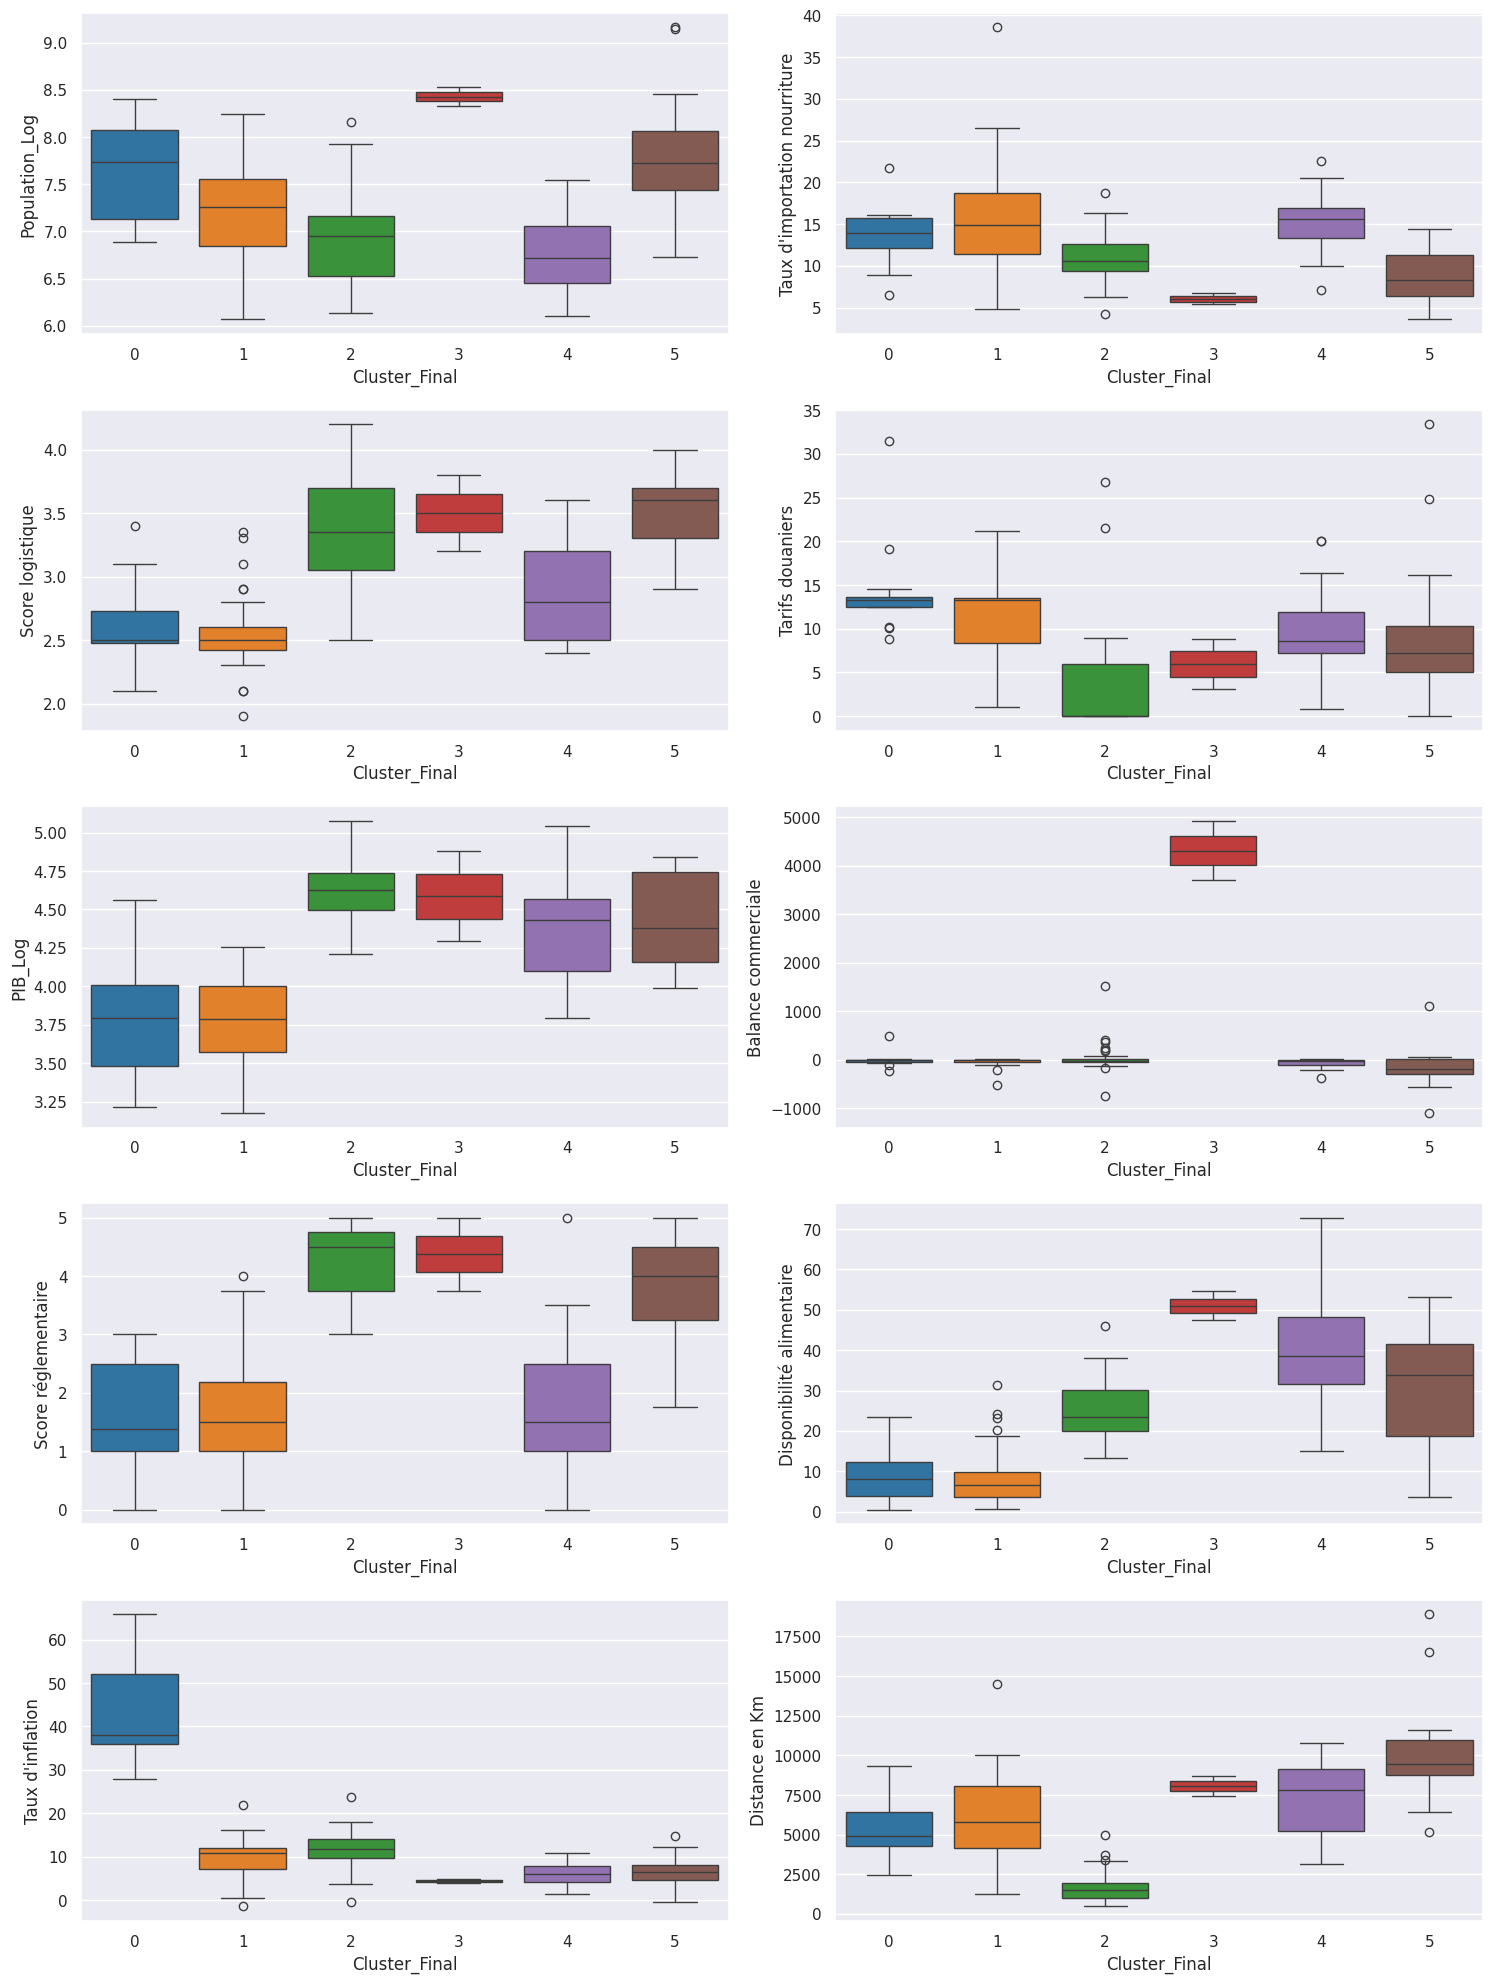

In [486]:
# Je représente la dispersion de chaque cluster à travers mes 10 variables originelles


# 2. Configuration de la zone de dessin
# Calcul du nombre de lignes nécessaires
n_cols = 2  # 2 graphiques par ligne pour que ce soit lisible
n_rows = (len(cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() # On aplatit pour pouvoir boucler facilement dessus

for i, variable in enumerate(cols):
    sns.boxplot(data=df,
                x='Cluster_Final',
                y=variable,
                hue='Cluster_Final',
                palette='tab10',
                legend=False,
                ax=axes[i])

plt.tight_layout()
plt.show()

### 4.4.2 Représentation visuelle

In [487]:
# 1. Création d'un DataFrame propre pour la fusion avec les clusters finaux
donnes_carte_final = df[['Country Code', 'Cluster_Final']].copy()

# 2. Fusion avec les données géographiques
map_gdf_final = countries_gdf.merge(donnes_carte_final, on='Country Code', how='left')

# Vérification des premières lignes après fusion
map_gdf_final.head()

,name,Country Code,ISO3166-1-Alpha-2,geometry,Cluster_Final
0,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4...",5.0
1,Malaysia,MYS,MY,"MULTIPOLYGON (((117.70361 4.16342, 117.69711 4...",5.0
2,Chile,CHL,CL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...",5.0
3,Bolivia,BOL,BO,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...",4.0
4,Peru,PER,PE,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...",4.0


In [488]:
# 2. On crée un petit tableau propre pour la fusion
# On ne garde que la clé (Country Code) et l'info à cartographier (Cluster)
donnees_carte = df[['Country Code', 'Cluster_Final']]

# Vérification
donnees_carte.head()

,Country Code,Cluster_Final
Country Name,,
Libye,LBY,1
Serbie,SRB,2
Papouasie-Nouvelle-Guinée,PNG,1
République démocratique du Congo,COD,1
Eswatini,SWZ,1


In [489]:
# Si vous repartez de votre objet geodataframe de base (countries_gdf)
map_gdf_clusters = countries_gdf.merge(donnees_carte, on='Country Code', how='left')


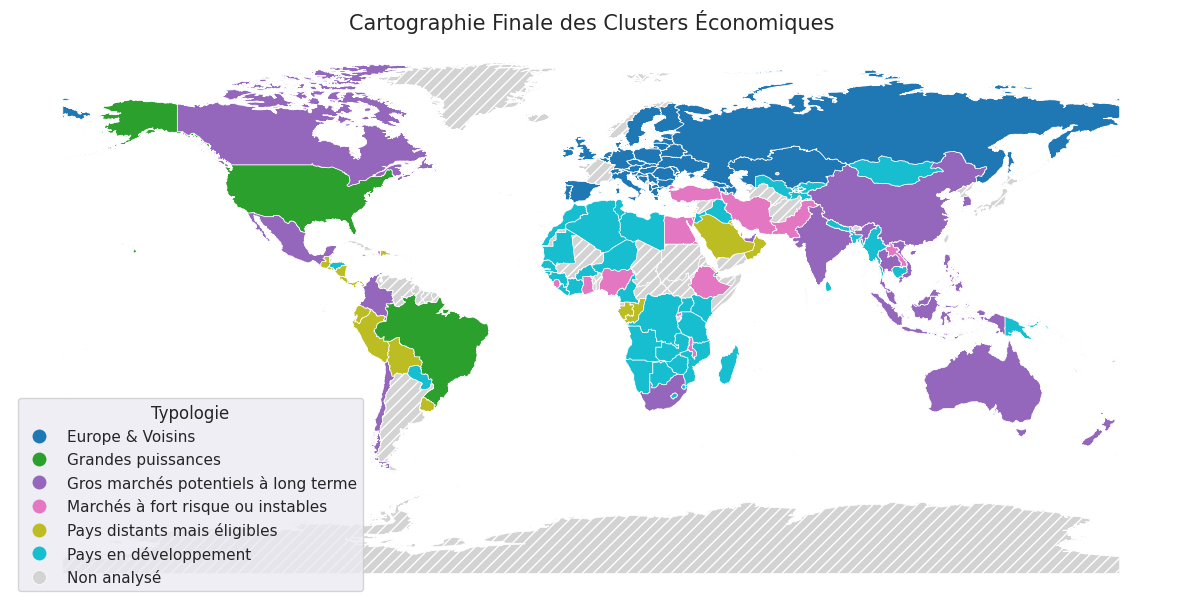

In [490]:
# On crée un dictionnaire pour renommer les clusters
# Adaptez les noms selon votre interprétation finale
legend_labels = {
    0: "Marchés à fort risque ou instables",
    1: "Pays en développement",
    2: "Europe & Voisins",
    3: "Grandes puissances",
    4: "Pays distants mais éligibles",
    5: "Gros marchés potentiels à long terme"
}

# On applique le mapping sur une copie pour l'affichage
map_display = map_gdf_clusters.copy()
map_display['Cluster_Nom'] = map_display['Cluster_Final'].map(legend_labels)

# On trace avec la nouvelle colonne 'Cluster_Nom'
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

map_display.plot(
    column='Cluster_Nom',    # On utilise les noms au lieu des chiffres
    ax=ax,
    categorical=True,
    legend=True,
    cmap='tab10',
    linewidth=0.5,
    edgecolor='white',
    missing_kwds={"color": "lightgrey", "label": "Non analysé", "hatch": "///"},
    legend_kwds={'loc': 'lower left', 'title': "Typologie"}
)

ax.set_title("Cartographie Finale des Clusters Économiques", fontsize=15)
ax.set_axis_off()
plt.show()

In [491]:
# Les trois premiers axes captant un plus de 54 % de la variance, il peut être révélateur de visualiser en 3D, notamment au regard des clusters 2 et 3 dont les nuages se chevauchent un peu.

# Création d'un DataFrame temporaire pour Plotly
df_3d = pd.DataFrame({
        'PC1': X_proj[:, 0],
        'PC2': X_proj[:, 1],
        'PC3': X_proj[:, 2],
        'Cluster': clusters_CAH.astype(str),  # Use the clusters_CAH array directly
        'Pays': names             # Pour voir le nom en passant la souris
    })

# Génération du graphique interactif
fig = px.scatter_3d(
        df_3d,
        x='PC1', y='PC2', z='PC3',
        color='Cluster',
        hover_name='Pays',
        opacity=0.7,                  # Transparence pour voir à travers le nuage
        size_max=10,
        title="Projection 3D des Clusters (PC1, PC2, PC3)"
    )

fig.show()

In [492]:
df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,...,Taux d'inflation,PIB par habitant,Score réglementaire,Population,Distance en Km,Population_Log,PIB_Log,Cluster CAH,Cluster K_means,Cluster_Final
Country Name,,,,,,,,,,,,,,,,,,,,,
Libye,Libye,31.28,-97.0,LBY,LY,Africa,Northern Africa,NaN,13.29,13.977771,...,13.85,12583.833873,0.0,7381023.0,1989.087,6.868117,4.099813,2,4,1
Serbie,Serbie,17.69,-17.0,SRB,RS,Europe,Southern Europe,NaN,0.00,12.252844,...,18.10,26900.783403,4.5,6587202.0,1226.467,6.818701,4.429765,3,1,2
Papouasie-Nouvelle-Guinée,Papouasie-Nouvelle-Guinée,3.97,-34.0,PNG,PG,Oceania,Melanesia,NaN,1.01,8.695478,...,8.25,4288.528290,1.5,10576502.0,14488.950,7.024342,3.632308,2,4,1
République démocratique du Congo,République démocratique du Congo,0.76,-71.0,COD,CD,Africa,Sub-Saharan Africa,Middle Africa,13.29,4.767380,...,10.85,1602.074980,1.0,109276265.0,5762.769,8.038526,3.204683,2,4,1
Eswatini,Eswatini,4.55,-3.0,SWZ,SZ,Africa,Sub-Saharan Africa,Southern Africa,6.13,19.582639,...,10.85,10380.396663,1.0,1242822.0,8628.108,6.094409,4.016214,2,4,1


In [493]:
# On ne prend que les variables qui racontent une histoire différente
cols_vip = [
    "PIB_Log",    # Représente la Richesse
    "Population_Log",      # Représente la Taille (Mieux que Population brute car moins écrasé)
    "Tarifs douaniers",    # Représente le Protectionnisme
    "Distance en Km",      # Représente la Géographie
    "Cluster_Final"        # Indispensable pour la couleur
]

<Figure size 1500x1500 with 0 Axes>

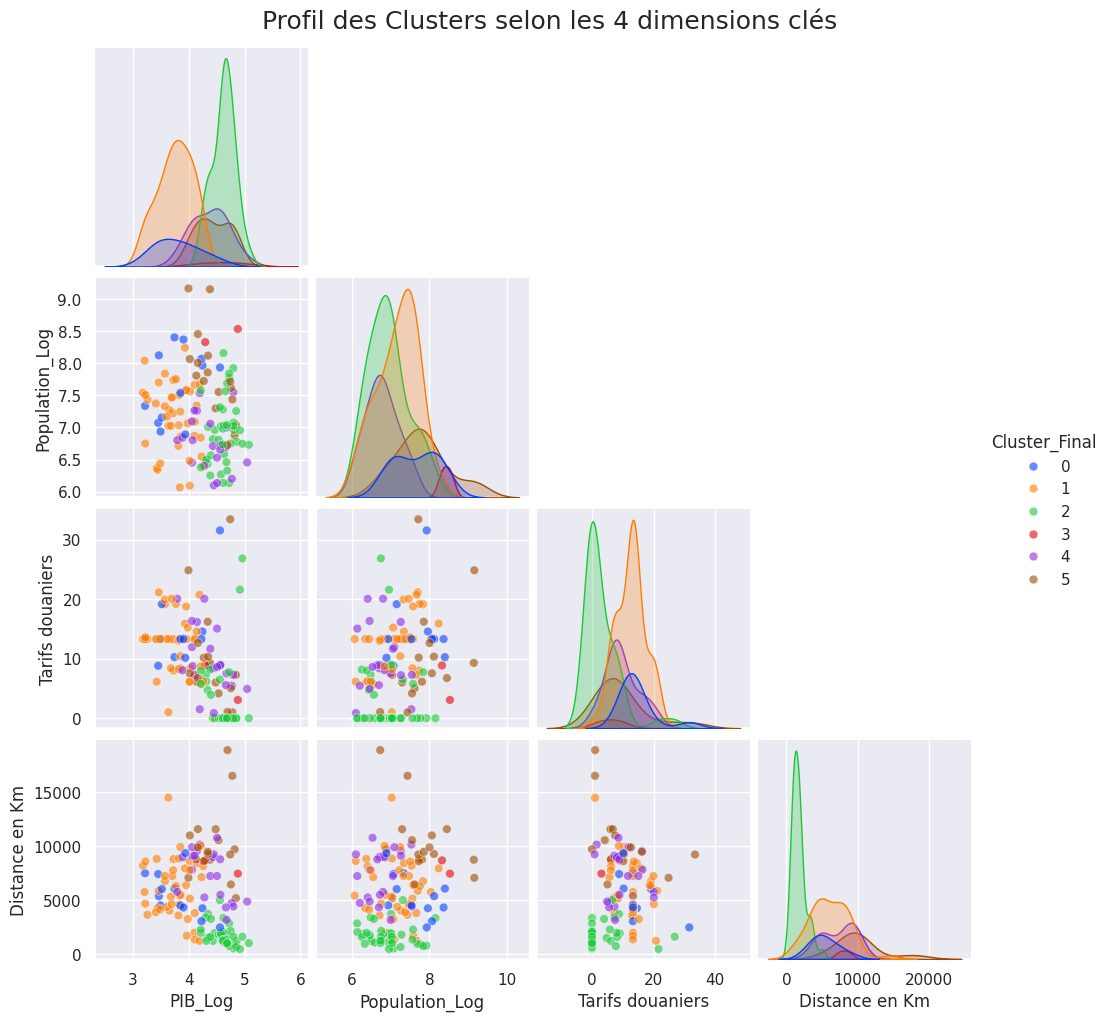

In [494]:
# Création du visuel
plt.figure(figsize=(15, 15))
sns.pairplot(
    df[cols_vip],
    hue="Cluster_Final",
    palette="bright",
    corner=True,
    plot_kws={'alpha': 0.6, 's': 40}
)

plt.suptitle("Profil des Clusters selon les 4 dimensions clés", y=1.02, fontsize=18)
plt.show()

# 5 Conclusion

In [495]:
poids = {
    'CP1': 0.4,   # C'est l'axe de la puissance économique, il est à privilégier
    'CP2': 0.1,   # C'est l'axe de la population
    'CP3': -0.2,  # L'axe de la distance, pour une première incursion à l'international, importer à l'autre bout de la planète n'est pas le plus aisé
    'CP4': 0.2,   # L'axe des pays qui importent
    'CP5': -0.1,  # L'axe de l'inflation, je mets une pénalité
    'CP6': -0.1   # L'axe du protectionnisme, il est préférable de viser des marchés relativement ouvert au regard de notre gamme de prix
}

Le scoring

In [496]:
# Création de df_projected à partir de X_projected
df_projected = pd.DataFrame(X_proj, columns=[f'CP{i+1}' for i in range(X_proj.shape[1])])

#Je récupère les valeurs
df_projected['Country Name'] = df['Country Name'].values
df_projected['Cluster_Final'] = df['Cluster_Final'].values

# Calcul du Score d'Attractivité
df_projected['Score_Attractivite'] = (
    df_projected['CP1'] * poids['CP1'] +
    df_projected['CP2'] * poids['CP2'] +
    df_projected['CP3'] * poids['CP3'] +
    df_projected['CP4'] * poids['CP4'] +
    df_projected['CP5'] * poids['CP5'] +
    df_projected['CP6'] * poids['CP6']
)

# 3. Normalisation (0 à 100)
min_score = df_projected['Score_Attractivite'].min()
max_score = df_projected['Score_Attractivite'].max()
df_projected['Note_Finale'] = ((df_projected['Score_Attractivite'] - min_score) / (max_score - min_score)) * 100

# 4. Affichage du TOP 15
top_pays = df_projected.sort_values(by='Note_Finale', ascending=False)

print("--- TOP 15 PAYS CIBLES (Score Pondéré sur Axes ACP) ---")
display(top_pays[['Country Name', 'Note_Finale', 'Cluster_Final']].head(15))

--- TOP 15 PAYS CIBLES (Score Pondéré sur Axes ACP) ---


,Country Name,Note_Finale,Cluster_Final
94,États-Unis d'Amérique,100.000000,3
69,Brésil,92.704686,3
121,Pologne,83.018743,2
116,Pays-Bas (Royaume des),73.639054,2
63,Autriche,70.477444,2
59,Allemagne,69.444543,2
58,Belgique,68.567074,2
82,Italie,67.217634,2
92,Espagne,67.033225,2
99,Hongrie,66.767134,2


Analyse des clusters :

Le cluster 2 est la cible prioritaire au regard de la puissance économique de ces pays (et donc de leur niveau de vie) et de la facilité de commerce pour un grand nombre d'entre eux (pays de l'union européenne sans barrières dounanières).
Une vigialnce est à garder concernant la situation géopolitique : Ukraine, Russie.

Le cluster 3 contient des pays à forte économie mais éloignés géographiquement. Les deux géants asiatiques y sont notamment. Certains de ses semblent correspondre au profils de nos clients potentiels mais ils semblent être en deuxième vague dans notre stratégie d'export.

Le cluster 3 est le plus réduit : Brésil et USA. Ce sont des économies puissantes avec un niveaui de vie qui permet l'export de notree type de marchandise mais ce sont aussi des puissances agricoles fortes ou la concurrence est plus présente. Cela demandera une stratégie spécifique, notamment au niveau marketing, par exemple sur l'image de marque des produits français.

Le cluster 3 est constitué de pays avec des économies émergentes, ou il est plus dificile de placer nos produits. Il cumule un ou plusieurs contraintes : douanières, logistique ou inflation élevé.

